In [68]:
# ── Notebook 9: Human-in-the-Loop (HITL) ───────────────────────────────
# Goal  : require human approval before the chatbot executes web searches.
# New   :
#   interrupt()         – pauses the graph and surfaces a payload to the
#                         caller; resumes when .invoke() gets Command(resume=)
#   Command(goto=...)   – dynamically routes to a different node
#   human_approval_node – HITL gate: approved->tools, rejected->END
#   route_tools()       – custom router replacing tools_condition:
#                         duckduckgo_search->human_approval
#                         other tools->tools | no call->END
# ─────────────────────────────────────────────────────────────────────────

!uv pip install langgraph langchain langchain-core langchain-community chromadb pypdf langchain-google-genai ddgs langchain-mistralai dotenv langgraph-checkpoint-sqlite --quiet

In [69]:
# ── Imports ──────────────────────────────────────────────────────────────
# TypedDict / Annotated / Literal  – typed state schema helpers
# BaseMessage / HumanMessage / AIMessage / ToolMessage – LangChain message types
# ChatMistralAI                    – Mistral AI chat model wrapper
# add_messages                     – reducer: appends msgs instead of overwriting
# StateGraph / START / END         – graph builder and sentinel nodes
# ToolNode / tools_condition       – prebuilt tool executor node and router
# MemorySaver / SqliteSaver        – in-RAM / SQLite-backed checkpointers
# interrupt / Command              – HITL primitives (pause & resume graph)
# trim_messages                    – slice message history to fit token budget

from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AnyMessage, AIMessage, ToolMessage
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv

from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool

from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import Chroma

from langgraph.types import interrupt, Command

import requests

In [70]:
# Load environment variables from .env (MISTRAL_API_KEY, LANGCHAIN_API_KEY, etc.).

load_dotenv()

True

In [71]:
llm = ChatMistralAI()

In [72]:
# ── Document Loading ────────────────────────────────────────────────────
# PyPDFLoader reads the PDF page-by-page, returning one Document per page
# with text content and metadata (page number, source path).

loader = PyPDFLoader("./../../resources/research-papers/yolo_melanoma_final.pdf")
docs = loader.load()

In [73]:
# Sanity check: print the number of pages loaded from the PDF.

len(docs)

4

In [74]:
# ── Text Splitting ──────────────────────────────────────────────────────
# RecursiveCharacterTextSplitter divides pages into overlapping chunks
# so each chunk fits within the embedding model's token limit.
# chunk_size=1000, chunk_overlap=200 preserves cross-boundary context.

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [75]:
# ── Embeddings & Vector Store ───────────────────────────────────────────
# Each chunk is converted to a dense vector via Google's embedding model.
# Chroma stores them in a local collection for fast similarity search.

embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001",)
vector_store = vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="./chroma_database",
)

In [76]:
vector_store

In [77]:
# ── Retriever ───────────────────────────────────────────────────────────
# Wraps the Chroma collection with a similarity-search interface.
# k=4 returns the 4 most semantically relevant chunks per query.

retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [78]:
# ── RAG Tool ────────────────────────────────────────────────────────────
# @tool exposes retrieve-from-vector-store as a callable LangChain tool.
# The LLM will invoke this when the user asks document-specific questions.

@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [79]:
# tools
search_tool = DuckDuckGoSearchRun(region="us-en")

In [80]:
# ── Stock Price Tool ────────────────────────────────────────────────────
# @tool that calls the Alpha Vantage API to fetch the latest stock quote.
# The LLM passes the ticker symbol; the function returns raw JSON.

@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    r = requests.get(url)
    return r.json()

In [81]:
# ── Calculator Tool ─────────────────────────────────────────────────────
# @tool for basic arithmetic (add/sub/mul/div) on two floats.
# Avoids the LLM making arithmetic errors by delegating to Python.

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}

In [82]:
# Make tool list
tools = [get_stock_price, search_tool, calculator, rag_tool]

# Make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

In [83]:
# ── Graph State ─────────────────────────────────────────────────────────
# ChatState is the single shared data structure flowing through the graph.
# add_messages reducer ensures new messages are *appended*, not replaced.

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [84]:
# ── Chat Node (uses llm_with_tools) ──────────────────────────────────────
# Uses llm_with_tools (not bare llm) so the model can emit tool_calls
# that trigger the HITL routing logic.

def chat_node(state: ChatState):
    """LLM node that decides to answer directly or call a tool."""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

In [85]:
# --- HITL routing logic ---

def route_tools(state: ChatState):
    """
    Called after chat_node to decide where to go next:
      - No tool call        → END  (LLM answered directly)
      - duckduckgo_search   → human_approval  (needs human sign-off)
      - Any other tool      → tools  (execute immediately)
    """
    last_message = state["messages"][-1]
    if not getattr(last_message, "tool_calls", None):
        return END
    tool_name = last_message.tool_calls[0]["name"]
    if tool_name == "duckduckgo_search":
        return "human_approval"
    return "tools"


def human_approval_node(state: ChatState):
    """
    Pauses the graph and asks a human to approve or reject the
    pending web-search call.
      - Approved  → Command(goto='tools')  — proceeds to execute the search
      - Rejected  → Command(goto=END)      — returns a rejection message
    """
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[0]

    decision = interrupt({
        "type": "approval",
        "tool_name": tool_call["name"],
        "query": tool_call["args"].get("query", str(tool_call["args"])),
        "instruction": "Web search requires human approval. Approve? (yes/no)"
    })

    if decision.get("approved") == "no":
        # Mistral requires a ToolMessage for every tool_call in the history.
        # Without it, the next turn sends an unmatched tool_call → 400 error.
        # We insert a cancellation ToolMessage to satisfy that constraint.
        return Command(
            goto=END,
            update={"messages": [
                ToolMessage(
                    content="Cancelled: rejected by human reviewer.",
                    tool_call_id=tool_call["id"]
                ),
                AIMessage(content="❌ Web search was rejected by the human reviewer.")
            ]}
        )

    # Approved → proceed to tool execution
    return Command(goto="tools")

In [86]:
# ── SQLite Connection ────────────────────────────────────────────────────
# Open (or create) chatbot.db. check_same_thread=False allows the
# connection to be used from the graph's internal threads safely.

conn = sqlite3.connect(database="chatbot.db", check_same_thread=False)
# checkpointer
checkpointer = SqliteSaver(conn=conn)

In [87]:
# ── Graph Construction (three nodes) ─────────────────────────────────────
# chat_node      – LLM decides action
# tools          – executes approved tool calls
# human_approval – HITL gate pausing for user confirmation

# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_node("human_approval", human_approval_node)  # HITL gate for web search

In [88]:
# ── Graph Edges with HITL Routing ────────────────────────────────────────
# route_tools drives three paths:
#   duckduckgo_search -> human_approval -> (approved) tools -> chat_node
#                                       -> (rejected) END
#   other tools  -> tools -> chat_node
#   no tool call -> END
# human_approval uses Command(goto=...) so no explicit outgoing edge needed.

graph.add_edge(START, "chat_node")
# Route: no tools → END | duckduckgo_search → human_approval | other tools → tools
graph.add_conditional_edges("chat_node", route_tools, ["human_approval", "tools", END])
graph.add_edge("tools", "chat_node")
# human_approval uses Command for dynamic routing — no explicit edge needed

In [89]:
# ── Compile the Graph ───────────────────────────────────────────────────
# compile() locks the graph structure and wires in the checkpointer.
# After this call the graph is immutable and ready to run.

chatbot = graph.compile(
    checkpointer=checkpointer
)

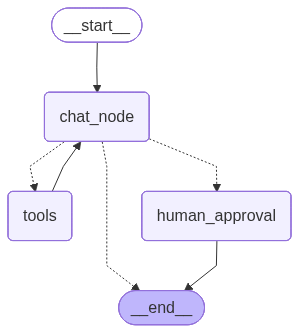

In [90]:
chatbot

In [91]:
# initial_state = {
#     'messages': [HumanMessage(content="What is the capital of India?")]
# }
# chatbot.invoke(initial_state)['messages'][-1].content

In [92]:
# ── Thread Selection ────────────────────────────────────────────────────
# List existing threads from the SQLite checkpoint so users can resume
# a previous conversation. Each thread_id is a UUID string.

import uuid

# --- Thread selection ---
# The 'checkpoints' table is created by SqliteSaver on the first save.
# On a fresh database it won't exist yet, so we catch that error and
# treat it the same as having no previous threads.
try:
    existing = conn.execute(
        "SELECT DISTINCT thread_id FROM checkpoints ORDER BY thread_id"
    ).fetchall()
except Exception:
    existing = []

if existing:
    print('Existing threads:')
    for i, (tid,) in enumerate(existing, 1):
        print(f'  [{i}] {tid}')
    print(f'  [n] Start a new thread')
    choice = input('Select a thread number or "n" for new: ').strip().lower()
    if choice == 'n' or not choice.isdigit():
        thread_id = str(uuid.uuid4())
        print(f'New thread created: {thread_id}')
    else:
        idx = int(choice) - 1
        thread_id = existing[idx][0]
        print(f'Resuming thread: {thread_id}')
else:
    thread_id = str(uuid.uuid4())
    print(f'No existing threads found. New thread created: {thread_id}')

Existing threads:
  [1] 07193a44-42d2-44d8-a435-ab2a44d07ffb
  [2] b7800c3c-ad6e-4fad-91e7-436921390d78
  [3] df7f51c0-31c0-49fe-8e75-7f5b8dcddb6d
  [4] e49f5b05-af1e-4b5f-ad38-9128def84e13
  [n] Start a new thread
New thread created: 763b24fe-02a9-4835-b357-7c508588093c


In [95]:
# --- Chat loop ---
while True:

    user_query = input('Ask your query: ')
    print('User: ', user_query)

    if not user_query.strip():
        print('Please enter a non-empty query.')
        continue

    if user_query.strip().lower() in ['exit', 'bye', 'fuck you', 'quit']:
        print('AI: Hope you got answers')
        break

    config = {
        'configurable': {
            'thread_id': thread_id,
            'metadata': {'thread_id': thread_id},
            'run_name': 'chat_turn'
        }
    }

    # input_data starts as the user message; may become Command(resume=...) after an interrupt
    input_data = {'messages': [HumanMessage(content=user_query)]}

    # Loop so we can re-stream after resuming from a human-approval interrupt
    while True:
        interrupted = False

        # stream_mode=["messages", "updates"]:
        #   "messages" → yields (chunk, metadata) tuples for real-time token streaming
        #   "updates"  → yields {node: output} dicts so we can catch __interrupt__ events
        for mode, data in chatbot.stream(
            input_data, config=config, stream_mode=["messages", "updates"]
        ):
            if mode == "messages":
                # Real-time token streaming — skip tool-call-only chunks
                chunk, _ = data
                if hasattr(chunk, 'content') and chunk.content and not getattr(chunk, 'tool_calls', None):
                    print(chunk.content, end='', flush=True)

            elif mode == "updates":
                for node_name, node_output in data.items():
                    if node_name == '__interrupt__':
                        # ---- Human-in-the-Loop: web search approval ----
                        interrupt_info = node_output[0].value
                        print(f"\n\n\ud83d\udd0d [HUMAN APPROVAL REQUIRED]")
                        print(f"   Tool  : {interrupt_info.get('tool_name')}")
                        print(f"   Query : {interrupt_info.get('query')}")
                        approval = input("   Approve web search? (yes/no): ").strip().lower()
                        # Resume the graph with the human's decision
                        input_data = Command(resume={"approved": approval})
                        interrupted = True

        if not interrupted:
            break   # No interrupt this pass — conversation turn is complete

    print()

User:  what is yolo?
**YOLO** (short for **"You Only Look Once"**) is a **real-time object detection algorithm** that has gained immense popularity in the field of **computer vision**. It is designed to detect and classify objects in images or videos in a single forward pass of a neural network, making it extremely fast and efficient.

---

## 🌟 **Key Features of YOLO**
1. **Real-Time Performance**:
   - YOLO processes images in **real-time** (e.g., 30+ frames per second on a GPU), making it ideal for applications like autonomous driving, surveillance, and robotics.

2. **Single Forward Pass**:
   - Unlike traditional object detection methods (e.g., R-CNN, which requires multiple passes), YOLO divides the image into a grid and predicts bounding boxes and class probabilities in **one go**.

3. **Unified Detection**:
   - YOLO combines **bounding box prediction** and **classification** into a single neural network, simplifying the pipeline.

4. **High Accuracy**:
   - Despite its speed, 